# Notebook 5: Fine-Tuned BERT
### Sarcasm Detection in News Headlines — NLP Project
---
**Model:** `bert-base-uncased` fine-tuned for binary sarcasm classification

**Why BERT is ideal for sarcasm:**
BERT uses self-attention to relate EVERY word to every other word simultaneously.
Sarcasm often depends on the relationship between the subject and predicate
(e.g., *"Nation's poor inspired by billionaire's hard work"*) — exactly what
BERT's attention mechanism captures.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
sns.set_theme(style='whitegrid')

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 64      # headlines are short — 64 is more than enough
BATCH_SIZE = 32
EPOCHS     = 4
LR         = 2e-5

Device: cpu


## 1. Load Data

In [3]:
with open('../data/splits.pkl', 'rb') as f: splits = pickle.load(f)

X_train = splits['X_raw_train']
X_val   = splits['X_raw_val']
X_test  = splits['X_raw_test']
y_train = list(splits['y_train'])
y_val   = list(splits['y_val'])
y_test  = list(splits['y_test'])

print(f'Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}')
print(f'Sample: "{X_train[0]}"')

Train: 20,031, Val: 4,293, Test: 4,293
Sample: "apathy outpacing lust as leading u.s. state of mind"


## 2. Tokenizer & Dataset

In [4]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded. Vocab size: {tokenizer.vocab_size:,}')

# Example
enc = tokenizer(X_train[0], max_length=MAX_LEN, truncation=True,
                padding='max_length', return_tensors='pt')
print(f'Input shape: {enc["input_ids"].shape}')
print(f'Tokens: {tokenizer.convert_ids_to_tokens(enc["input_ids"][0])[:15]}')

Tokenizer loaded. Vocab size: 30,522
Input shape: torch.Size([1, 64])
Tokens: ['[CLS]', 'ap', '##athy', 'out', '##pac', '##ing', 'lust', 'as', 'leading', 'u', '.', 's', '.', 'state', 'of']


In [10]:
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, truncation=True,
            padding='max_length', return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(SarcasmDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SarcasmDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SarcasmDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Batches — Train: 626, Val: 135, Test: 135


## 3. Load BERT

In [6]:
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    output_attentions=False, output_hidden_states=False
).to(device)

total     = sum(p.numel() for p in bert_model.parameters())
trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13017.66it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

Total parameters    : 109,483,778
Trainable parameters: 109,483,778


## 4. Optimizer & Scheduler

In [7]:
optimizer    = AdamW(bert_model.parameters(), lr=LR, eps=1e-8, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f'Total steps: {total_steps}, Warmup: {warmup_steps}')

Total steps: 2504, Warmup: 250


## 5. Training Loop

In [11]:
def run_epoch(model, loader, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    all_preds = []; all_labels = []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval', leave=False):
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            labs  = batch['label'].to(device)
            out   = model(input_ids=ids, attention_mask=mask, labels=labs)
            loss, logits = out.loss, out.logits
            if train:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labs).sum().item()
            total   += labs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels


tr_losses=[]; vl_losses=[]; tr_accs=[]; vl_accs=[]
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}  {"-"*40}')
    tr_loss, tr_acc, _, _ = run_epoch(bert_model, train_loader, optimizer, scheduler, train=True)
    vl_loss, vl_acc, _, _ = run_epoch(bert_model, val_loader, train=False)
    tr_losses.append(tr_loss); vl_losses.append(vl_loss)
    tr_accs.append(tr_acc);   vl_accs.append(vl_acc)
    print(f'  Train → Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}')
    print(f'  Val   → Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(bert_model.state_dict(), '../data/best_bert.pt')
        print(f'  ✓ Best saved (val_acc={best_val_acc:.4f})')

print(f'\nDone! Best val accuracy: {best_val_acc:.4f}')


Epoch 1/4  ----------------------------------------


  Train → Loss: 0.3465  Acc: 0.8415
  Val   → Loss: 0.2200  Acc: 0.9152
  ✓ Best saved (val_acc=0.9152)

Epoch 2/4  ----------------------------------------


  Train → Loss: 0.1392  Acc: 0.9496
  Val   → Loss: 0.2044  Acc: 0.9283
  ✓ Best saved (val_acc=0.9283)

Epoch 3/4  ----------------------------------------


  Train → Loss: 0.0646  Acc: 0.9807
  Val   → Loss: 0.3709  Acc: 0.9115

Epoch 4/4  ----------------------------------------


  Train → Loss: 0.0318  Acc: 0.9913
  Val   → Loss: 0.3289  Acc: 0.9313
  ✓ Best saved (val_acc=0.9313)

Done! Best val accuracy: 0.9313


## 6. Training Curves

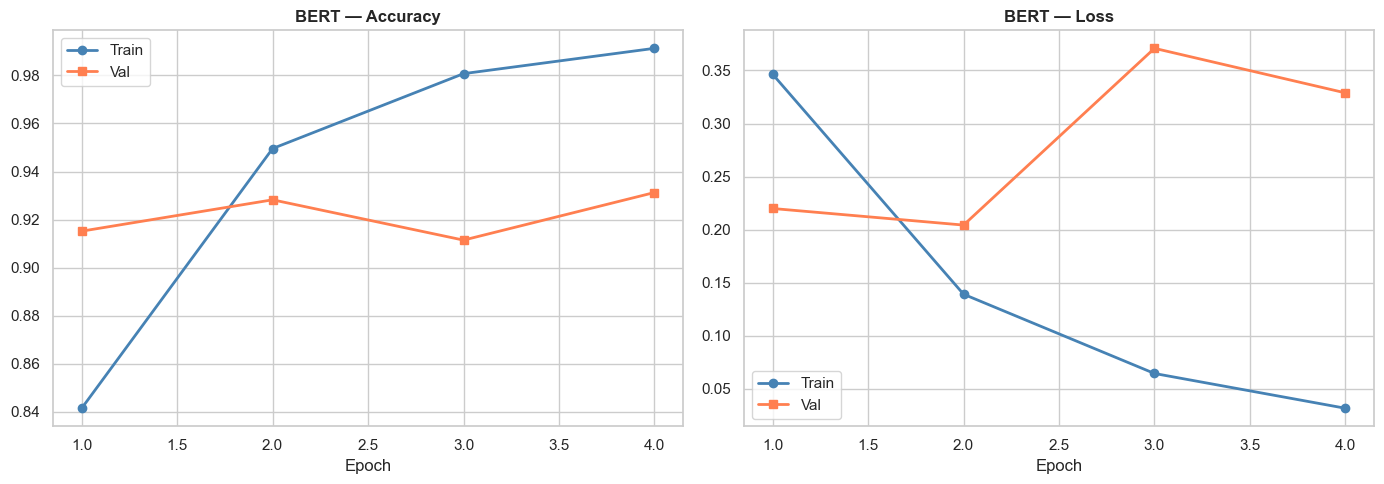

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, EPOCHS+1)
for ax, tr, vl, title in [
    (axes[0], tr_accs,   vl_accs,   'Accuracy'),
    (axes[1], tr_losses, vl_losses, 'Loss')
]:
    ax.plot(ep, tr, marker='o', label='Train', color='steelblue', lw=2)
    ax.plot(ep, vl, marker='s', label='Val',   color='coral',     lw=2)
    ax.set_title(f'BERT — {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig('../outputs/05_bert_history.png', dpi=150)
plt.show()

## 7. Evaluate Best Model


  Model: BERT (fine-tuned)
  Accuracy : 0.9294
  Precision: 0.9296
  Recall   : 0.9294
  F1-Score : 0.9294

               precision    recall  f1-score   support

Not Sarcastic       0.92      0.94      0.93      2248
    Sarcastic       0.94      0.91      0.93      2045

     accuracy                           0.93      4293
    macro avg       0.93      0.93      0.93      4293
 weighted avg       0.93      0.93      0.93      4293



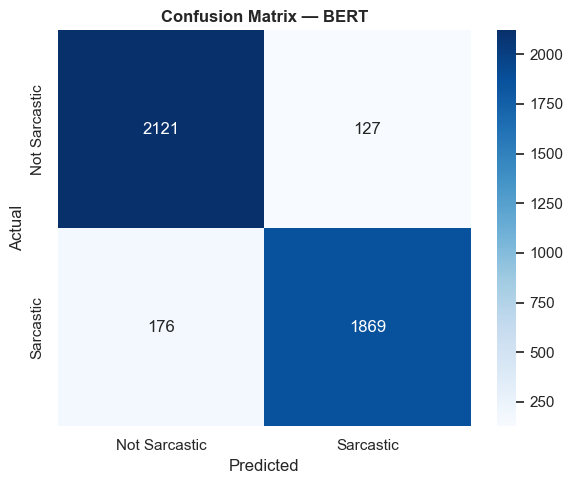


All F1 scores: {'Naive Bayes': 0.7878, 'Logistic Regression': 0.7854, 'SVM': 0.7954, 'BiLSTM': 0.8689, 'BERT': 0.9294}


In [13]:
bert_model.load_state_dict(torch.load('../data/best_bert.pt', map_location=device))
_, _, preds, true = run_epoch(bert_model, test_loader, train=False)

acc  = accuracy_score(true, preds)
prec = precision_score(true, preds, average='weighted')
rec  = recall_score(true, preds, average='weighted')
f1   = f1_score(true, preds, average='weighted')

print(f'\n{"="*52}'); print('  Model: BERT (fine-tuned)'); print(f'{"="*52}')
print(f'  Accuracy : {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'\n{classification_report(true, preds, target_names=["Not Sarcastic","Sarcastic"])}')

cm = confusion_matrix(true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarcastic','Sarcastic'],
            yticklabels=['Not Sarcastic','Sarcastic'])
plt.title('Confusion Matrix — BERT', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/cm_bert.png', dpi=150)
plt.show()

with open('../data/results.pkl', 'rb') as f: results = pickle.load(f)
results['BERT'] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)
with open('../data/results.pkl', 'wb') as f: pickle.dump(results, f)
print('\nAll F1 scores:', {k: round(v["F1"],4) for k,v in results.items()})